# Aula Prática (Parte 1) — Redes Neurais *Multilayer Perceptron* (MLP)

## 0. Importando as bibliotecas

Usamos o `scikit-learn`, a mesma biblioteca por trás de muitos modelos que veremos.
Para redes neurais ela traz a classe `MLPClassifier`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf

# deixa os gráficos aparecerem dentro do notebook
%matplotlib inline
np.random.seed(42) # reprodutibilidade

I0000 00:00:1779826795.295902   44993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779826795.296534   44993 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779826795.884891   44993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779826798.495979   44993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 1. Por que o MLP? O problema do XOR


| Entrada A | Entrada B | AND | OR | XOR |
|:---:|:---:|:---:|:---:|:---:|
| 0 | 0 | 0 | 0 | **0** |
| 0 | 1 | 0 | 1 | **1** |
| 1 | 0 | 0 | 1 | **1** |
| 1 | 1 | 1 | 1 | **0** |

O **AND** e o **OR** o perceptron resolve. Mas o **XOR** **não é separável por uma reta**


In [4]:
# Tabela-verdade do XOR
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([0, 1, 1, 0])   # saída esperada do XOR

print("Entradas:\n", X_xor)
print("Saída esperada (XOR):", y_xor)

Entradas:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Saída esperada (XOR): [0 1 1 0]


### 1.1 O perceptron tentando resolver o XOR

In [5]:
perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(X_xor, y_xor)

pred_perc = perceptron.predict(X_xor)
print("Esperado :", y_xor)
print("Previsto :", pred_perc)
print(f"Acurácia : {accuracy_score(y_xor, pred_perc):.0%}")

Esperado : [0 1 1 0]
Previsto : [0 0 0 0]
Acurácia : 50%


In [6]:
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(4,),   # 1 camada oculta com 4 neurônios
    activation="tanh",         # função de ativação não-linear
    solver="adam",
    max_iter=5000,
    random_state=0
)
mlp_xor.fit(X_xor, y_xor)

pred_mlp = mlp_xor.predict(X_xor)
print("Esperado :", y_xor)
print("Previsto :", pred_mlp)
print(f"Acurácia : {accuracy_score(y_xor, pred_mlp):.0%}")   # 100%!

Esperado : [0 1 1 0]
Previsto : [0 1 1 0]
Acurácia : 100%


### 1.3 Visualizando a fronteira de decisão

A imagem deixa claro: o perceptron só traça uma **reta**; o MLP cria uma
**fronteira curva (não-linear)** capaz de separar o XOR.

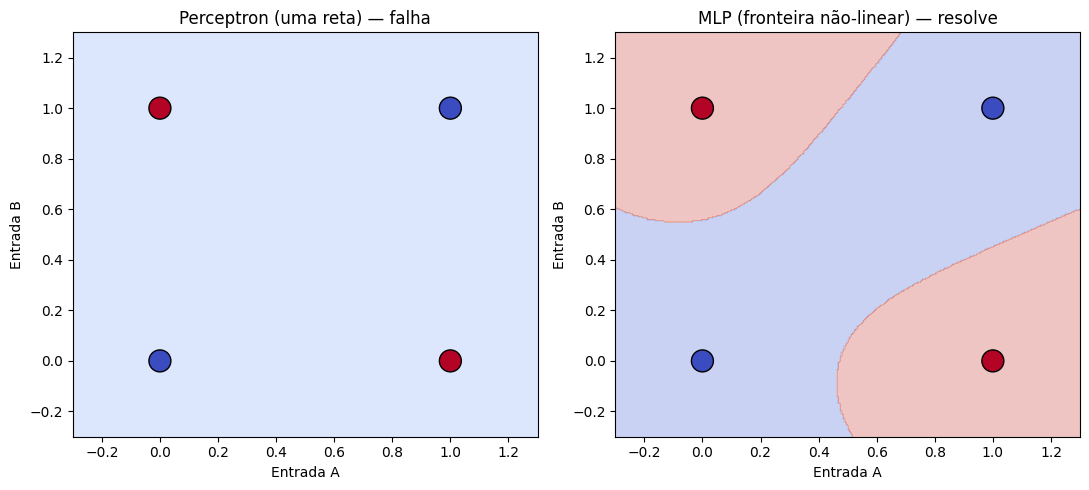

In [7]:
def plot_fronteira(modelo, X, y, titulo, ax):
    # cria uma grade de pontos e pinta a região de cada classe
    xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 300),
                         np.linspace(-0.3, 1.3, 300))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, s=250, edgecolor="k", cmap="coolwarm")
    ax.set_title(titulo)
    ax.set_xlabel("Entrada A"); ax.set_ylabel("Entrada B")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_fronteira(perceptron, X_xor, y_xor, "Perceptron (uma reta) — falha", axes[0])
plot_fronteira(mlp_xor,    X_xor, y_xor, "MLP (fronteira não-linear) — resolve", axes[1])
plt.tight_layout(); plt.show()

## 2. Pipeline completo com um dataset real: Iris

Agora vamos do "brinquedo" (XOR) para um problema real. Usaremos o **Iris**
(o mesmo da Aula 04): classificar flores em **3 espécies** a partir de **4 medidas**
(comprimento/largura da sépala e da pétala).

O pipeline é o **mesmo de qualquer modelo supervisionado**:
**carregar → explorar → separar treino/teste → normalizar → treinar → avaliar**.

In [8]:
cancer = load_breast_cancer()
X = cancer.data          # 569 amostras x 30 atributos
y = cancer.target        # classe: 0=maligno, 1=benigno

# Montamos um DataFrame só para visualizar melhor
df = pd.DataFrame(X, columns=cancer.feature_names)
df["especie"] = [cancer.target_names[i] for i in y]
print("Formato dos dados:", X.shape)
print("Classes:", cancer.target_names)
df.head()

Formato dos dados: (569, 30)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,especie
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


### 2.1 Separando treino e teste (Holdout)

`stratify=y` mantém a **mesma proporção de classes** nos dois conjuntos.

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.30,      # 30% para teste
    random_state=42,     # resultado reproduzível
    stratify=y           # mantém proporção das 3 classes
)
print("Treino:", X_treino.shape[0], "amostras")
print("Teste :", X_teste.shape[0], "amostras")

Treino: 398 amostras
Teste : 171 amostras


### 2.2 Normalização (pré-processamento)

Como vimos na aula de **normalização**, atributos em escalas diferentes atrapalham o aprendizado. Em redes neurais isso é ainda mais sério, porque os **pesos** e o **gradiente** ficam desbalanceados e o treino fica lento ou instável.

Usamos o `StandardScaler` (média 0, desvio 1).

Ajustamos o scaler **só no treino** (`fit_transform`) e apenas **aplicamos** no teste (`transform`) — para não "vazar" informação do teste.

In [10]:
scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino)   # aprende a escala NO TREINO
X_teste_norm  = scaler.transform(X_teste)        # apenas aplica no teste

print("Antes  (1ª amostra):", X_treino[0])
print("Depois (1ª amostra):", X_treino_norm[0].round(2))

Antes  (1ª amostra): [1.162e+01 1.818e+01 7.638e+01 4.088e+02 1.175e-01 1.483e-01 1.020e-01
 5.564e-02 1.957e-01 7.255e-02 4.101e-01 1.740e+00 3.027e+00 2.785e+01
 1.459e-02 3.206e-02 4.961e-02 1.841e-02 1.807e-02 5.217e-03 1.336e+01
 2.540e+01 8.814e+01 5.281e+02 1.780e-01 2.878e-01 3.186e-01 1.416e-01
 2.660e-01 9.270e-02]
Depois (1ª amostra): [-0.71 -0.26 -0.64 -0.71  1.63  0.85  0.17  0.2   0.54  1.35  0.08  1.
  0.15 -0.3   2.51  0.36  0.52  1.08 -0.3   0.49 -0.6  -0.07 -0.57 -0.62
  2.02  0.19  0.18  0.4  -0.41  0.45]


## 3. Treinando o MLP

Cada hiperparâmetro abaixo corresponde a um conceito da teoria:

| Hiperparâmetro | O que é | Conexão com a teoria |
|---|---|---|
| `hidden_layer_sizes=(8, 8)` | nº de neurônios em cada **camada oculta** | aqui: 2 camadas de 8 neurônios |
| `activation="relu"` | **função de ativação** dos neurônios | introduz a **não-linearidade** |
| `solver="adam"` | algoritmo de otimização | versão moderna do **gradiente descendente** |
| `learning_rate_init=0.01` | **taxa de aprendizado** | tamanho do passo a cada ajuste de peso |
| `max_iter=1000` | nº máximo de **épocas** | quantas vezes percorre os dados no treino |

O `fit` executa o **backpropagation** que vocês viram na teoria: a rede faz uma
previsão, calcula o erro e ajusta os pesos camada por camada.

In [11]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8, 8),   # 2 camadas ocultas, 8 neurônios cada
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_treino_norm, y_treino)   # <-- aqui acontece o treinamento (backpropagation)
print("Treinamento concluído!")
print("Convergiu em", mlp.n_iter_, "épocas")

Treinamento concluído!
Convergiu em 116 épocas


## 4. Avaliando o modelo

In [12]:
prev = mlp.predict(X_teste_norm)

acc_treino = mlp.score(X_treino_norm, y_treino)
acc_teste  = accuracy_score(y_teste, prev)
print(f"Acurácia no TREINO: {acc_treino:.1%}")
print(f"Acurácia no TESTE : {acc_teste:.1%}")

Acurácia no TREINO: 100.0%
Acurácia no TESTE : 97.1%


### 4.2 Relatório por classe

`precision`, `recall` e `f1-score` por espécie — métricas da Aula 09.

In [13]:
print(classification_report(y_teste, prev, target_names=cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.94      0.98      0.96        64
      benign       0.99      0.96      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



### 4.3 Matriz de confusão

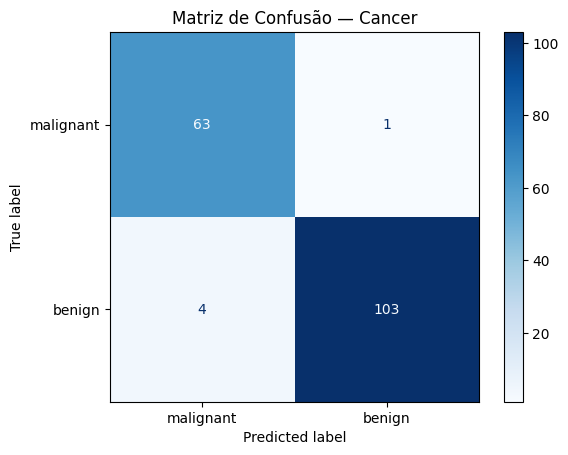

In [14]:
cm = confusion_matrix(y_teste, prev)
disp = ConfusionMatrixDisplay(cm, display_labels=cancer.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão — Cancer")
plt.show()

### 4.4 Curva de perda (*loss*)

A rede ajusta os pesos para **minimizar o erro (loss)** a cada época.
Uma curva que **desce e estabiliza** indica que o treino convergiu bem.

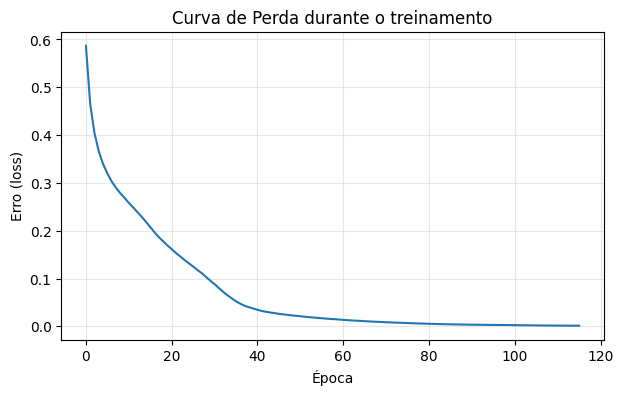

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.title("Curva de Perda durante o treinamento")
plt.xlabel("Época"); plt.ylabel("Erro (loss)")
plt.grid(alpha=0.3); plt.show()

## 5. Experimentando a arquitetura + validação cruzada

### 5.1 Mudando o número de neurônios/camadas

A **arquitetura** (quantos neurônios e camadas) muda o poder do modelo.

In [16]:
arquiteturas = [(2,), (8,), (8, 8), (50, 50)]

for arq in arquiteturas:
    m = MLPClassifier(hidden_layer_sizes=arq, max_iter=1000, random_state=42)
    m.fit(X_treino_norm, y_treino)
    tr = m.score(X_treino_norm, y_treino)
    te = m.score(X_teste_norm, y_teste)
    print(f"Camadas {str(arq):10s} -> treino: {tr:.1%} | teste: {te:.1%}")

Camadas (2,)       -> treino: 98.0% | teste: 95.3%
Camadas (8,)       -> treino: 99.0% | teste: 97.7%
Camadas (8, 8)     -> treino: 99.0% | teste: 97.7%
Camadas (50, 50)   -> treino: 100.0% | teste: 97.1%


### 5.2 Validação cruzada (k-fold)

In [17]:
# normalizamos todo o X para a validação cruzada
X_norm = StandardScaler().fit_transform(X)

modelo_cv = MLPClassifier(hidden_layer_sizes=(8, 8), max_iter=1000, random_state=42)
scores = cross_val_score(modelo_cv, X_norm, y, cv=5)   # 5-fold

print("Acurácia em cada fold:", np.round(scores, 3))
print(f"Média: {scores.mean():.1%}  (+/- {scores.std():.1%})")

Acurácia em cada fold: [0.982 0.965 0.965 0.974 0.982]
Média: 97.4%  (+/- 0.8%)


# Aula Prática (Parte 2)

In [19]:
df['especie'] = df['especie'].replace({'malignant':0,
                                       'benign':1}) # Adaptando os valores de string para numericos no estilo "sparse"

/tmp/ipykernel_44993/341303728.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['especie'] = df['especie'].replace({'malignant':0,


# Divisão treino-teste

In [20]:
X = df.drop(columns=['especie'])
y = df['especie']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Padronizando os Dados

In [22]:
scaler = StandardScaler() # Instanciando padronizador de dados do sklearn
scaler.fit(X_train) # Adequamos o padronizador aos dados de treino

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Rede Neural

In [35]:
model = tf.keras.Sequential([
       tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [36]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Treino

In [37]:
BATCH_SIZE = 4
EPOCHS = 30
model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.8793 - loss: 0.2799
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.9764 - loss: 0.0984
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.9790 - loss: 0.0713
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.9843 - loss: 0.0572
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.9895 - loss: 0.0476
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.9895 - loss: 0.0407 
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.9921 - loss: 0.0333
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.9948 - loss: 0.0250
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.9895 - loss: 0.0276
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9948 - loss: 0.0197
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.9974 - loss: 0.0133
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

# Testando modelo

In [38]:
model.evaluate(X_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9628 - loss: 0.1373  


[0.13731268048286438, 0.9627659320831299]

## Obtendo mais métricas

In [39]:
y_pred = model.predict(X_test)
y_pred

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([[2.52311118e-03, 9.97476876e-01],
       [1.00000000e+00, 2.89461346e-14],
       [1.00000000e+00, 1.38700651e-09],
       [1.12386056e-08, 1.00000000e+00],
       [4.61525096e-10, 1.00000000e+00],
       [1.00000000e+00, 3.28001523e-36],
       [1.00000000e+00, 1.92818729e-26],
       [9.99884248e-01, 1.15701012e-04],
       [9.04719174e-01, 9.52808335e-02],
       [1.59348531e-07, 9.99999881e-01],
       [7.36455396e-02, 9.26354408e-01],
       [9.99962687e-01, 3.73167968e-05],
       [2.19884423e-05, 9.99978065e-01],
       [9.99993205e-01, 6.78273682e-06],
       [1.15916168e-06, 9.99998808e-01],
       [1.00000000e+00, 7.33150574e-13],
       [4.48495882e-07, 9.99999523e-01],
       [1.95444744e-10, 1.00000000e+00],
       [1.36026552e-12, 1.00000000e+00],
       [1.00000000e+00, 4.25792709e-18],
       [2.32324397e-04, 9.99767721e-01],
       [1.06703656e-05, 9.99989271e-01],
       [1.00000000e+00, 1.79775293e-28],
       [7.06638161e-08, 9.99999881e-01],
       [1.088441

In [40]:
y_pred = [np.argmax(v) for v in y_pred]
y_pred

[np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.in

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        67
           1       0.98      0.96      0.97       121

    accuracy                           0.96       188
   macro avg       0.96      0.96      0.96       188
weighted avg       0.96      0.96      0.96       188

